In [1]:
# ============================================================
# Training-only univariate t-test CpG screening + ridge model
# Case/control and cycle phase
# ============================================================

In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
out_dir = "/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs"
os.makedirs(out_dir, exist_ok=True)

cc_out_dir = os.path.join(out_dir, "case_control")
cp_out_dir = os.path.join(out_dir, "cycle_phase")

os.makedirs(cc_out_dir, exist_ok=True)
os.makedirs(cp_out_dir, exist_ok=True)

print("Main output directory:", out_dir)
print("Case/control output directory:", cc_out_dir)
print("Cycle phase output directory:", cp_out_dir)

Main output directory: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs
Case/control output directory: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control
Cycle phase output directory: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase


In [4]:
adata = sc.read_h5ad(
    "/mnt/efs/home/ubuntu/M_smartsva_corrected_with_SH_annot_filtered.h5ad"
)

print(adata)
print(adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 984 × 759345
    obs: 'sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source'
['sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source']


In [5]:
def to_dense(X):
    if sp.issparse(X):
        return X.toarray()
    return np.asarray(X)

In [6]:
def run_ttest_screening(X_train, y_train, feature_names, out_csv=None):
    """
    Runs per-CpG two-sample t-tests using training data only.
    Assumes y_train is binary: 0 vs 1.
    """

    group0 = X_train[y_train == 0]
    group1 = X_train[y_train == 1]

    print("Group 0 shape:", group0.shape)
    print("Group 1 shape:", group1.shape)

    t_stats, p_values = ttest_ind(
        group1,
        group0,
        axis=0,
        equal_var=False,
        nan_policy="omit"
    )

    mean_group0 = np.nanmean(group0, axis=0)
    mean_group1 = np.nanmean(group1, axis=0)

    mean_diff = mean_group1 - mean_group0
    abs_mean_diff = np.abs(mean_diff)

    results_df = pd.DataFrame({
        "CpG": feature_names,
        "t_stat": t_stats,
        "p_value": p_values,
        "mean_group0": mean_group0,
        "mean_group1": mean_group1,
        "mean_diff_group1_minus_group0": mean_diff,
        "abs_mean_diff": abs_mean_diff
    })

    # FDR correction across all CpGs tested
    valid_pvals = results_df["p_value"].notna()

    results_df["FDR"] = np.nan
    results_df.loc[valid_pvals, "FDR"] = multipletests(
        results_df.loc[valid_pvals, "p_value"].values,
        alpha=0.05,
        method="fdr_bh"
    )[1]

    results_df = results_df.sort_values(
        "FDR",
        ascending=True,
        na_position="last"
    ).reset_index(drop=True)

    total_cpgs_tested = len(results_df)
    fdr_sig_cpgs = (results_df["FDR"] < 0.05).sum()
    percent_retained = 100 * fdr_sig_cpgs / total_cpgs_tested

    print("\n==============================")
    print("T-TEST FEATURE SELECTION SUMMARY")
    print("==============================")
    print(f"Total CpGs tested: {total_cpgs_tested}")
    print(f"CpGs passing FDR < 0.05: {fdr_sig_cpgs}")
    print(f"Percent retained: {percent_retained:.4f}%")
    print("==============================\n")

    if out_csv is not None:
        results_df.to_csv(out_csv, index=False)
        print("Saved t-test results to:", out_csv)

    return results_df

In [7]:
def evaluate_binary_model(model, X_test, y_test, out_prefix, plot_title):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "AUROC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    }

    metrics_df = pd.DataFrame([metrics])
    metrics_path = f"{out_prefix}_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)

    print("Saved metrics to:", metrics_path)
    display(metrics_df)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUROC = {metrics['AUROC']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{plot_title}: ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_roc_curve.png", dpi=300)
    plt.show()

    # PR curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(6, 6))
    plt.plot(recall_vals, precision_vals, label=f"AUPRC = {metrics['AUPRC']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{plot_title}: Precision-Recall Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_pr_curve.png", dpi=300)
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()
    plt.title(f"{plot_title}: Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_confusion_matrix.png", dpi=300)
    plt.show()

    return metrics_df

### Prepare Case vs control

In [8]:
adata_cc = adata[adata.obs["endo"].notna()].copy()

print(adata_cc.obs["endo"].value_counts(dropna=False))

endo
1    637
0    347
Name: count, dtype: Int64


In [9]:
y_cc_series = adata_cc.obs["endo"].map({
    "No": 0,
    "Yes": 1,
    "Control": 0,
    "Case": 1,
    0: 0,
    1: 1
})

valid_mask = y_cc_series.notna()

adata_cc = adata_cc[valid_mask].copy()
y_cc = y_cc_series[valid_mask].astype(int).values

X_cc = to_dense(adata_cc.X)
feature_names_cc = adata_cc.var_names.to_numpy()

print("X_cc shape:", X_cc.shape)
print("y_cc shape:", y_cc.shape)
print("Controls:", np.sum(y_cc == 0))
print("Cases:", np.sum(y_cc == 1))

X_cc shape: (984, 759345)
y_cc shape: (984,)
Controls: 347
Cases: 637


In [10]:
X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc,
    y_cc,
    test_size=0.20,
    random_state=42,
    stratify=y_cc
)

print("X_train_cc:", X_train_cc.shape)
print("X_test_cc:", X_test_cc.shape)
print("Train controls:", np.sum(y_train_cc == 0))
print("Train cases:", np.sum(y_train_cc == 1))
print("Test controls:", np.sum(y_test_cc == 0))
print("Test cases:", np.sum(y_test_cc == 1))

X_train_cc: (787, 759345)
X_test_cc: (197, 759345)
Train controls: 278
Train cases: 509
Test controls: 69
Test cases: 128


In [11]:
cc_ttest_ranked = run_ttest_screening(
    X_train=X_train_cc,
    y_train=y_train_cc,
    feature_names=feature_names_cc,
    out_csv=os.path.join(cc_out_dir, "case_control_ttest_all_cpgs_with_FDR.csv")
)

cc_ttest_selected_cpgs = cc_ttest_ranked.loc[
    cc_ttest_ranked["FDR"] < 0.05,
    "CpG"
].tolist()

cc_ttest_n = len(cc_ttest_selected_cpgs)

cc_selected_path = os.path.join(
    cc_out_dir,
    f"case_control_ttest_FDR_0.05_selected_cpgs_n{cc_ttest_n}.csv"
)

pd.Series(cc_ttest_selected_cpgs, name="CpG").to_csv(cc_selected_path, index=False)

print("Case/control FDR-significant CpGs:", cc_ttest_n)
print("Saved selected CpGs to:", cc_selected_path)

cc_ttest_ranked.head(20)

Group 0 shape: (278, 759345)
Group 1 shape: (509, 759345)

T-TEST FEATURE SELECTION SUMMARY
Total CpGs tested: 759345
CpGs passing FDR < 0.05: 0
Percent retained: 0.0000%

Saved t-test results to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control/case_control_ttest_all_cpgs_with_FDR.csv
Case/control FDR-significant CpGs: 0
Saved selected CpGs to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control/case_control_ttest_FDR_0.05_selected_cpgs_n0.csv


,CpG,t_stat,p_value,mean_group0,mean_group1,mean_diff_group1_minus_group0,abs_mean_diff,FDR
0,cg05587394,5.335260,1.297799e-07,1.030102,1.233727,0.203625,0.203625,0.098548
1,cg07706375,4.842381,1.651740e-06,-0.017114,0.035443,0.052557,0.052557,0.156780
2,cg25856265,-4.901340,1.217581e-06,-0.351114,-0.450640,-0.099526,0.099526,0.156780
3,cg04415176,4.938191,1.042322e-06,-3.324861,-2.972736,0.352125,0.352125,0.156780
4,cg09976716,4.896849,1.326703e-06,4.903820,5.106935,0.203115,0.203115,0.156780
5,cg25044850,4.865170,1.468889e-06,0.802045,0.894138,0.092093,0.092093,0.156780
6,cg11136960,4.891213,1.308491e-06,2.500768,2.647723,0.146955,0.146955,0.156780
7,cg02177811,4.909169,1.190200e-06,-1.280592,-1.185361,0.095232,0.095232,0.156780
8,cg22241571,-4.810216,1.859168e-06,2.670861,2.399632,-0.271229,0.271229,0.156861
9,cg21965065,4.704593,3.187976e-06,3.062761,3.118650,0.055889,0.055889,0.172912


In [12]:
if cc_ttest_n == 0:
    print("No case/control CpGs passed FDR < 0.05.")
    print("Skipping case/control t-test ridge model.")
    X_train_cc_ttest_sel = None
    X_test_cc_ttest_sel = None
else:
    cpg_to_idx_cc = {cpg: i for i, cpg in enumerate(feature_names_cc)}

    selected_idx_cc = [cpg_to_idx_cc[cpg] for cpg in cc_ttest_selected_cpgs]

    X_train_cc_ttest_sel = X_train_cc[:, selected_idx_cc]
    X_test_cc_ttest_sel = X_test_cc[:, selected_idx_cc]

    print("X_train_cc_ttest_sel:", X_train_cc_ttest_sel.shape)
    print("X_test_cc_ttest_sel:", X_test_cc_ttest_sel.shape)

No case/control CpGs passed FDR < 0.05.
Skipping case/control t-test ridge model.


In [13]:
if cc_ttest_n > 0:
    ridge_cc_ttest = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=0.000215,
            solver="lbfgs",
            max_iter=5000
        ))
    ])

    ridge_cc_ttest.fit(X_train_cc_ttest_sel, y_train_cc)

    print("Finished training case/control ridge model using FDR-significant t-test CpGs.")
else:
    ridge_cc_ttest = None

In [14]:
if cc_ttest_n > 0:
    cc_ttest_metrics = evaluate_binary_model(
        model=ridge_cc_ttest,
        X_test=X_test_cc_ttest_sel,
        y_test=y_test_cc,
        out_prefix=os.path.join(
            cc_out_dir,
            f"case_control_ttest_FDR_0.05_n{cc_ttest_n}_ridge"
        ),
        plot_title=f"Case vs Control, T-test FDR < 0.05 CpGs n={cc_ttest_n}"
    )

    cc_ttest_metrics
else:
    cc_ttest_metrics = pd.DataFrame([{
        "AUROC": np.nan,
        "AUPRC": np.nan,
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "Note": "No CpGs passed FDR < 0.05; model skipped"
    }])

    cc_ttest_metrics

### Cycle phase

In [15]:
print(adata.obs["cycle-phase"].value_counts(dropna=False))

cycle-phase
PE           473
MSE          209
ESE          122
LSE          108
Menstrual     50
SE            22
Name: count, dtype: int64


In [16]:
adata_cp = adata[adata.obs["cycle-phase"].notna()].copy()

y_cp_series = adata_cp.obs["cycle-phase"].map({
    "PE": 0,
    "P": 0,
    "Proliferative": 0,
    "proliferative": 0,
    "ESE": 1,
    "MSE": 1,
    "LSE": 1,
    "SE": 1,
    "Secretory": 1,
    "secretory": 1
})

valid_mask = y_cp_series.notna()

adata_cp = adata_cp[valid_mask].copy()
y_cp = y_cp_series[valid_mask].astype(int).values

X_cp = to_dense(adata_cp.X)
feature_names_cp = adata_cp.var_names.to_numpy()

print("X_cp shape:", X_cp.shape)
print("y_cp shape:", y_cp.shape)
print("Proliferative:", np.sum(y_cp == 0))
print("Secretory:", np.sum(y_cp == 1))

X_cp shape: (934, 759345)
y_cp shape: (934,)
Proliferative: 473
Secretory: 461


In [17]:
X_train_cp, X_test_cp, y_train_cp, y_test_cp = train_test_split(
    X_cp,
    y_cp,
    test_size=0.20,
    random_state=42,
    stratify=y_cp
)

print("X_train_cp:", X_train_cp.shape)
print("X_test_cp:", X_test_cp.shape)
print("Train proliferative:", np.sum(y_train_cp == 0))
print("Train secretory:", np.sum(y_train_cp == 1))
print("Test proliferative:", np.sum(y_test_cp == 0))
print("Test secretory:", np.sum(y_test_cp == 1))

X_train_cp: (747, 759345)
X_test_cp: (187, 759345)
Train proliferative: 378
Train secretory: 369
Test proliferative: 95
Test secretory: 92


In [18]:
cp_ttest_ranked = run_ttest_screening(
    X_train=X_train_cp,
    y_train=y_train_cp,
    feature_names=feature_names_cp,
    out_csv=os.path.join(cp_out_dir, "cycle_phase_ttest_all_cpgs_with_FDR.csv")
)

cp_ttest_selected_cpgs = cp_ttest_ranked.loc[
    cp_ttest_ranked["FDR"] < 0.05,
    "CpG"
].tolist()

cp_ttest_n = len(cp_ttest_selected_cpgs)

cp_selected_path = os.path.join(
    cp_out_dir,
    f"cycle_phase_ttest_FDR_0.05_selected_cpgs_n{cp_ttest_n}.csv"
)

pd.Series(cp_ttest_selected_cpgs, name="CpG").to_csv(cp_selected_path, index=False)

print("Cycle phase FDR-significant CpGs:", cp_ttest_n)
print("Saved selected CpGs to:", cp_selected_path)

cp_ttest_ranked.head(20)

Group 0 shape: (378, 759345)
Group 1 shape: (369, 759345)

T-TEST FEATURE SELECTION SUMMARY
Total CpGs tested: 759345
CpGs passing FDR < 0.05: 32386
Percent retained: 4.2650%

Saved t-test results to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase/cycle_phase_ttest_all_cpgs_with_FDR.csv
Cycle phase FDR-significant CpGs: 32386
Saved selected CpGs to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase/cycle_phase_ttest_FDR_0.05_selected_cpgs_n32386.csv


,CpG,t_stat,p_value,mean_group0,mean_group1,mean_diff_group1_minus_group0,abs_mean_diff,FDR
0,cg02594094,-18.167103,0.0,2.040777,1.540844,-0.499933,0.499933,0.0
1,cg22253251,-15.605729,0.0,2.710016,2.236634,-0.473381,0.473381,0.0
2,cg01433297,-15.618115,0.0,-0.985183,-1.523929,-0.538746,0.538746,0.0
3,cg26522002,16.036310,0.0,1.977725,2.575997,0.598273,0.598273,0.0
4,cg06011205,-15.479183,0.0,1.520654,1.168126,-0.352528,0.352528,0.0
5,cg20680797,-18.348558,0.0,2.074237,1.547378,-0.526859,0.526859,0.0
6,cg16564333,-17.908306,0.0,2.007437,1.612211,-0.395227,0.395227,0.0
7,cg26332187,-16.225395,0.0,2.093747,1.519313,-0.574434,0.574434,0.0
8,cg25735294,-15.302711,0.0,2.908621,2.481813,-0.426808,0.426808,0.0
9,cg05941521,-22.331133,0.0,3.770906,2.931333,-0.839573,0.839573,0.0


In [19]:
if cp_ttest_n == 0:
    print("No cycle phase CpGs passed FDR < 0.05.")
    print("Skipping cycle phase t-test ridge model.")
    X_train_cp_ttest_sel = None
    X_test_cp_ttest_sel = None
else:
    cpg_to_idx_cp = {cpg: i for i, cpg in enumerate(feature_names_cp)}

    selected_idx_cp = [cpg_to_idx_cp[cpg] for cpg in cp_ttest_selected_cpgs]

    X_train_cp_ttest_sel = X_train_cp[:, selected_idx_cp]
    X_test_cp_ttest_sel = X_test_cp[:, selected_idx_cp]

    print("X_train_cp_ttest_sel:", X_train_cp_ttest_sel.shape)
    print("X_test_cp_ttest_sel:", X_test_cp_ttest_sel.shape)

X_train_cp_ttest_sel: (747, 32386)
X_test_cp_ttest_sel: (187, 32386)


In [20]:
if cp_ttest_n > 0:
    ridge_cp_ttest = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=0.000215,
            solver="lbfgs",
            max_iter=5000
        ))
    ])

    ridge_cp_ttest.fit(X_train_cp_ttest_sel, y_train_cp)

    print("Finished training cycle phase ridge model using FDR-significant t-test CpGs.")
else:
    ridge_cp_ttest = None

Finished training cycle phase ridge model using FDR-significant t-test CpGs.


Saved metrics to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase/cycle_phase_ttest_FDR_0.05_n32386_ridge_metrics.csv


,AUROC,AUPRC,Accuracy,Precision,Recall,F1
0,0.977346,0.980442,0.925134,0.953488,0.891304,0.921348


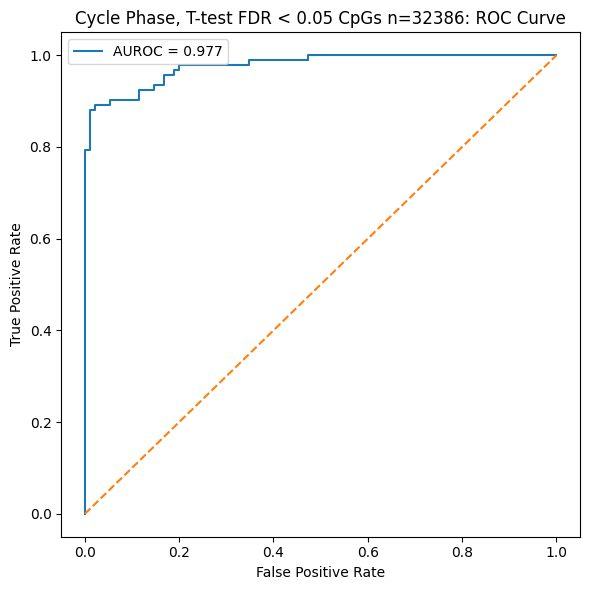

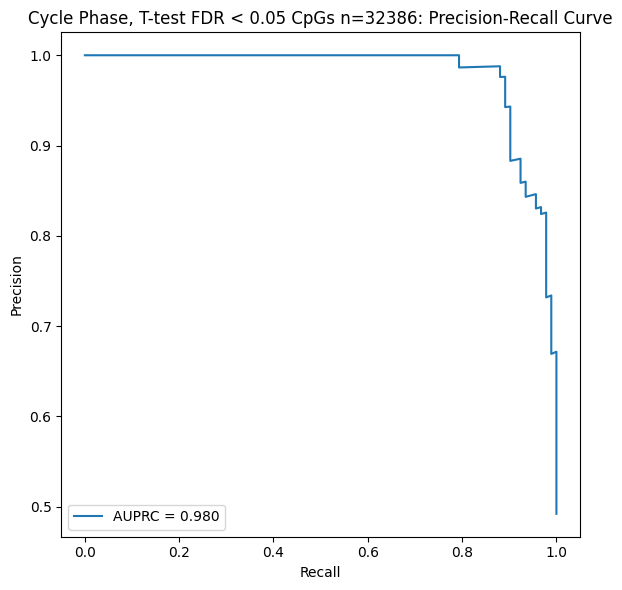

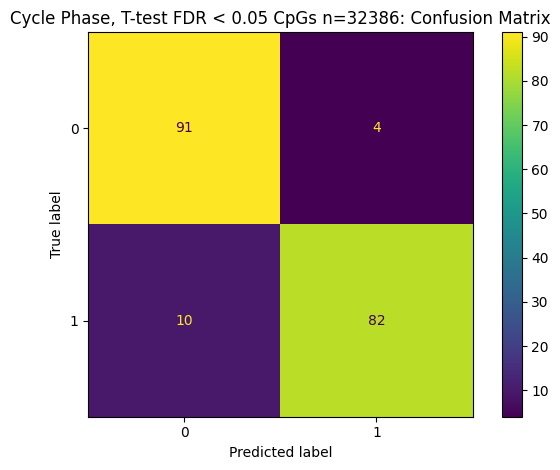

In [21]:
if cp_ttest_n > 0:
    cp_ttest_metrics = evaluate_binary_model(
        model=ridge_cp_ttest,
        X_test=X_test_cp_ttest_sel,
        y_test=y_test_cp,
        out_prefix=os.path.join(
            cp_out_dir,
            f"cycle_phase_ttest_FDR_0.05_n{cp_ttest_n}_ridge"
        ),
        plot_title=f"Cycle Phase, T-test FDR < 0.05 CpGs n={cp_ttest_n}"
    )

    cp_ttest_metrics
else:
    cp_ttest_metrics = pd.DataFrame([{
        "AUROC": np.nan,
        "AUPRC": np.nan,
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "Note": "No CpGs passed FDR < 0.05; model skipped"
    }])

    cp_ttest_metrics

In [22]:
cc_ttest_metrics_labeled = cc_ttest_metrics.copy()
cc_ttest_metrics_labeled.insert(0, "Outcome", "Case vs Control")
cc_ttest_metrics_labeled.insert(1, "Feature_Selection", f"T-test FDR < 0.05 n={cc_ttest_n}")

cp_ttest_metrics_labeled = cp_ttest_metrics.copy()
cp_ttest_metrics_labeled.insert(0, "Outcome", "Cycle Phase")
cp_ttest_metrics_labeled.insert(1, "Feature_Selection", f"T-test FDR < 0.05 n={cp_ttest_n}")

ttest_combined_metrics = pd.concat(
    [cc_ttest_metrics_labeled, cp_ttest_metrics_labeled],
    ignore_index=True
)

ttest_combined_metrics_path = os.path.join(
    out_dir,
    "ttest_FDR_0.05_ridge_combined_metrics.csv"
)

ttest_combined_metrics.to_csv(ttest_combined_metrics_path, index=False)

print("Saved combined metrics to:", ttest_combined_metrics_path)
ttest_combined_metrics

Saved combined metrics to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_FDR_0.05_ridge_combined_metrics.csv


,Outcome,Feature_Selection,AUROC,AUPRC,Accuracy,Precision,Recall,F1,Note
0,Case vs Control,T-test FDR < 0.05 n=0,NaN,NaN,NaN,NaN,NaN,NaN,No CpGs passed FDR < 0.05; model skipped
1,Cycle Phase,T-test FDR < 0.05 n=32386,0.977346,0.980442,0.925134,0.953488,0.891304,0.921348,NaN


#### after FDR correction, no CpGs were individually significant enough for case vs conrol. 32000 CpGs were signficant for cycle phase. 

## univariate logistic regression 

In [23]:
import statsmodels.api as sm
import warnings

from statsmodels.tools.sm_exceptions import PerfectSeparationError, ConvergenceWarning
from statsmodels.stats.multitest import multipletests

In [24]:
def run_univariate_logistic_screening(X_train, y_train, feature_names, out_csv=None):
    """
    Runs one univariate logistic regression per CpG using training data only.
    Assumes y_train is binary: 0 vs 1.

    Feature significance is based only on Benjamini-Hochberg FDR < 0.05.
    No -log10(p), no nominal p-value threshold, no top-N selection.
    """

    results = []

    for i, cpg in enumerate(feature_names):
        x_i = X_train[:, i]

        try:
            X_design = sm.add_constant(x_i, has_constant="add")

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)

                model = sm.Logit(y_train, X_design)
                fit = model.fit(disp=0, maxiter=100)

            coef = fit.params[1]
            p_value = fit.pvalues[1]

            results.append({
                "CpG": cpg,
                "coef": coef,
                "abs_coef": abs(coef),
                "p_value": p_value
            })

        except (PerfectSeparationError, np.linalg.LinAlgError, ValueError, IndexError):
            results.append({
                "CpG": cpg,
                "coef": np.nan,
                "abs_coef": np.nan,
                "p_value": np.nan
            })

        if (i + 1) % 10000 == 0:
            print(f"Processed {i + 1} / {len(feature_names)} CpGs")

    results_df = pd.DataFrame(results)

    valid_pvals = results_df["p_value"].notna()

    results_df["FDR"] = np.nan
    results_df.loc[valid_pvals, "FDR"] = multipletests(
        results_df.loc[valid_pvals, "p_value"].values,
        alpha=0.05,
        method="fdr_bh"
    )[1]

    results_df = results_df.sort_values(
        "FDR",
        ascending=True,
        na_position="last"
    ).reset_index(drop=True)

    total_cpgs_tested = len(results_df)
    fdr_sig_cpgs = (results_df["FDR"] < 0.05).sum()
    percent_retained = 100 * fdr_sig_cpgs / total_cpgs_tested

    print("\n==============================================")
    print("UNIVARIATE LOGISTIC FEATURE SELECTION SUMMARY")
    print("==============================================")
    print(f"Total CpGs tested: {total_cpgs_tested}")
    print(f"CpGs passing FDR < 0.05: {fdr_sig_cpgs}")
    print(f"Percent retained: {percent_retained:.4f}%")
    print("==============================================\n")

    if out_csv is not None:
        results_df.to_csv(out_csv, index=False)
        print("Saved univariate logistic results to:", out_csv)

    return results_df

In [25]:
cc_uni_out_dir = os.path.join(out_dir, "case_control_univariate_logistic")
os.makedirs(cc_uni_out_dir, exist_ok=True)

print(cc_uni_out_dir)

/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control_univariate_logistic


In [26]:
cc_uni_ranked = run_univariate_logistic_screening(
    X_train=X_train_cc,
    y_train=y_train_cc,
    feature_names=feature_names_cc,
    out_csv=os.path.join(
        cc_uni_out_dir,
        "case_control_univariate_logistic_all_cpgs_with_FDR.csv"
    )
)

cc_uni_ranked.head(20)

Processed 10000 / 759345 CpGs
Processed 20000 / 759345 CpGs
Processed 30000 / 759345 CpGs
Processed 40000 / 759345 CpGs
Processed 50000 / 759345 CpGs
Processed 60000 / 759345 CpGs
Processed 70000 / 759345 CpGs
Processed 80000 / 759345 CpGs
Processed 90000 / 759345 CpGs
Processed 100000 / 759345 CpGs
Processed 110000 / 759345 CpGs
Processed 120000 / 759345 CpGs
Processed 130000 / 759345 CpGs
Processed 140000 / 759345 CpGs
Processed 150000 / 759345 CpGs
Processed 160000 / 759345 CpGs
Processed 170000 / 759345 CpGs
Processed 180000 / 759345 CpGs
Processed 190000 / 759345 CpGs
Processed 200000 / 759345 CpGs
Processed 210000 / 759345 CpGs
Processed 220000 / 759345 CpGs
Processed 230000 / 759345 CpGs
Processed 240000 / 759345 CpGs
Processed 250000 / 759345 CpGs
Processed 260000 / 759345 CpGs
Processed 270000 / 759345 CpGs
Processed 280000 / 759345 CpGs
Processed 290000 / 759345 CpGs
Processed 300000 / 759345 CpGs
Processed 310000 / 759345 CpGs
Processed 320000 / 759345 CpGs
Processed 330000 

,CpG,coef,abs_coef,p_value,FDR
0,cg20308684,1.790427,1.790427,0.000050,0.302526
1,cg07467678,1.235145,1.235145,0.000033,0.302526
2,cg06375556,1.484581,1.484581,0.000073,0.302526
3,cg05678317,1.256549,1.256549,0.000088,0.302526
4,cg17173726,-1.705189,1.705189,0.000121,0.302526
5,cg08004561,1.041754,1.041754,0.000028,0.302526
6,cg10004716,-1.230579,1.230579,0.000057,0.302526
7,cg06002516,-0.973976,0.973976,0.000117,0.302526
8,cg13125224,-1.399105,1.399105,0.000121,0.302526
9,cg01235120,-1.222616,1.222616,0.000029,0.302526


In [27]:
fdr_threshold = 0.05

cc_uni_selected_cpgs = cc_uni_ranked.loc[
    cc_uni_ranked["FDR"] < fdr_threshold,
    "CpG"
].tolist()

cc_uni_n = len(cc_uni_selected_cpgs)

cc_uni_selected_path = os.path.join(
    cc_uni_out_dir,
    f"case_control_univariate_logistic_FDR_0.05_selected_cpgs_n{cc_uni_n}.csv"
)

pd.Series(cc_uni_selected_cpgs, name="CpG").to_csv(cc_uni_selected_path, index=False)

print("Case/control univariate logistic FDR-significant CpGs:", cc_uni_n)
print("Saved selected CpGs to:", cc_uni_selected_path)

Case/control univariate logistic FDR-significant CpGs: 0
Saved selected CpGs to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control_univariate_logistic/case_control_univariate_logistic_FDR_0.05_selected_cpgs_n0.csv


In [28]:
if cc_uni_n == 0:
    print("No case/control CpGs passed univariate logistic FDR < 0.05.")
    print("Skipping case/control univariate logistic ridge model.")
    X_train_cc_uni_sel = None
    X_test_cc_uni_sel = None
else:
    cpg_to_idx_cc = {cpg: i for i, cpg in enumerate(feature_names_cc)}

    selected_idx_cc_uni = [cpg_to_idx_cc[cpg] for cpg in cc_uni_selected_cpgs]

    X_train_cc_uni_sel = X_train_cc[:, selected_idx_cc_uni]
    X_test_cc_uni_sel = X_test_cc[:, selected_idx_cc_uni]

    print("X_train_cc_uni_sel:", X_train_cc_uni_sel.shape)
    print("X_test_cc_uni_sel:", X_test_cc_uni_sel.shape)

No case/control CpGs passed univariate logistic FDR < 0.05.
Skipping case/control univariate logistic ridge model.


In [29]:
if cc_uni_n > 0:
    ridge_cc_uni = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=0.000215,
            solver="lbfgs",
            max_iter=5000
        ))
    ])

    ridge_cc_uni.fit(X_train_cc_uni_sel, y_train_cc)

    print("Finished training case/control ridge model using univariate logistic FDR-significant CpGs.")
else:
    ridge_cc_uni = None

In [30]:
if cc_uni_n > 0:
    cc_uni_metrics = evaluate_binary_model(
        model=ridge_cc_uni,
        X_test=X_test_cc_uni_sel,
        y_test=y_test_cc,
        out_prefix=os.path.join(
            cc_uni_out_dir,
            f"case_control_univariate_logistic_FDR_0.05_n{cc_uni_n}_ridge"
        ),
        plot_title=f"Case vs Control, Univariate Logistic FDR < 0.05 CpGs n={cc_uni_n}"
    )

    cc_uni_metrics
else:
    cc_uni_metrics = pd.DataFrame([{
        "AUROC": np.nan,
        "AUPRC": np.nan,
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "Note": "No CpGs passed univariate logistic FDR < 0.05; model skipped"
    }])

    cc_uni_metrics

In [31]:
cp_uni_out_dir = os.path.join(out_dir, "cycle_phase_univariate_logistic")
os.makedirs(cp_uni_out_dir, exist_ok=True)

print(cp_uni_out_dir)

/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase_univariate_logistic


In [32]:
cp_uni_ranked = run_univariate_logistic_screening(
    X_train=X_train_cp,
    y_train=y_train_cp,
    feature_names=feature_names_cp,
    out_csv=os.path.join(
        cp_uni_out_dir,
        "cycle_phase_univariate_logistic_all_cpgs_with_FDR.csv"
    )
)

cp_uni_ranked.head(20)

Processed 10000 / 759345 CpGs
Processed 20000 / 759345 CpGs
Processed 30000 / 759345 CpGs
Processed 40000 / 759345 CpGs
Processed 50000 / 759345 CpGs
Processed 60000 / 759345 CpGs
Processed 70000 / 759345 CpGs
Processed 80000 / 759345 CpGs
Processed 90000 / 759345 CpGs
Processed 100000 / 759345 CpGs
Processed 110000 / 759345 CpGs
Processed 120000 / 759345 CpGs
Processed 130000 / 759345 CpGs
Processed 140000 / 759345 CpGs
Processed 150000 / 759345 CpGs
Processed 160000 / 759345 CpGs
Processed 170000 / 759345 CpGs
Processed 180000 / 759345 CpGs
Processed 190000 / 759345 CpGs
Processed 200000 / 759345 CpGs
Processed 210000 / 759345 CpGs
Processed 220000 / 759345 CpGs
Processed 230000 / 759345 CpGs
Processed 240000 / 759345 CpGs
Processed 250000 / 759345 CpGs
Processed 260000 / 759345 CpGs
Processed 270000 / 759345 CpGs
Processed 280000 / 759345 CpGs
Processed 290000 / 759345 CpGs
Processed 300000 / 759345 CpGs
Processed 310000 / 759345 CpGs
Processed 320000 / 759345 CpGs
Processed 330000 

,CpG,coef,abs_coef,p_value,FDR
0,cg16201273,-3.538752,3.538752,2.022571e-45,1.535829e-39
1,cg05941521,-3.182270,3.182270,3.282055e-44,1.246106e-38
2,cg18890101,-2.853854,2.853854,3.771869e-40,9.547167e-35
3,cg10123669,-3.240401,3.240401,2.637521e-39,5.006971e-34
4,cg20680797,-3.930767,3.930767,8.382703e-39,1.273073e-33
5,cg12710800,-3.725576,3.725576,1.015679e-38,1.285417e-33
6,cg07252961,-4.239084,4.239084,1.604017e-38,1.740003e-33
7,cg05466666,-4.898449,4.898449,2.571103e-38,2.440442e-33
8,cg08951452,-3.099916,3.099916,5.642948e-38,4.099524e-33
9,cg01130040,-3.540946,3.540946,6.478517e-38,4.099524e-33


In [33]:
fdr_threshold = 0.05

cp_uni_selected_cpgs = cp_uni_ranked.loc[
    cp_uni_ranked["FDR"] < fdr_threshold,
    "CpG"
].tolist()

cp_uni_n = len(cp_uni_selected_cpgs)

cp_uni_selected_path = os.path.join(
    cp_uni_out_dir,
    f"cycle_phase_univariate_logistic_FDR_0.05_selected_cpgs_n{cp_uni_n}.csv"
)

pd.Series(cp_uni_selected_cpgs, name="CpG").to_csv(cp_uni_selected_path, index=False)

print("Cycle phase univariate logistic FDR-significant CpGs:", cp_uni_n)
print("Saved selected CpGs to:", cp_uni_selected_path)

Cycle phase univariate logistic FDR-significant CpGs: 29749
Saved selected CpGs to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase_univariate_logistic/cycle_phase_univariate_logistic_FDR_0.05_selected_cpgs_n29749.csv


In [34]:
if cp_uni_n == 0:
    print("No cycle phase CpGs passed univariate logistic FDR < 0.05.")
    print("Skipping cycle phase univariate logistic ridge model.")
    X_train_cp_uni_sel = None
    X_test_cp_uni_sel = None
else:
    cpg_to_idx_cp = {cpg: i for i, cpg in enumerate(feature_names_cp)}

    selected_idx_cp_uni = [cpg_to_idx_cp[cpg] for cpg in cp_uni_selected_cpgs]

    X_train_cp_uni_sel = X_train_cp[:, selected_idx_cp_uni]
    X_test_cp_uni_sel = X_test_cp[:, selected_idx_cp_uni]

    print("X_train_cp_uni_sel:", X_train_cp_uni_sel.shape)
    print("X_test_cp_uni_sel:", X_test_cp_uni_sel.shape)

X_train_cp_uni_sel: (747, 29749)
X_test_cp_uni_sel: (187, 29749)


In [35]:
if cp_uni_n > 0:
    ridge_cp_uni = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=0.000215,
            solver="lbfgs",
            max_iter=5000
        ))
    ])

    ridge_cp_uni.fit(X_train_cp_uni_sel, y_train_cp)

    print("Finished training cycle phase ridge model using univariate logistic FDR-significant CpGs.")
else:
    ridge_cp_uni = None

Finished training cycle phase ridge model using univariate logistic FDR-significant CpGs.


Saved metrics to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase_univariate_logistic/cycle_phase_univariate_logistic_FDR_0.05_n29749_ridge_metrics.csv


,AUROC,AUPRC,Accuracy,Precision,Recall,F1
0,0.976316,0.979735,0.925134,0.953488,0.891304,0.921348


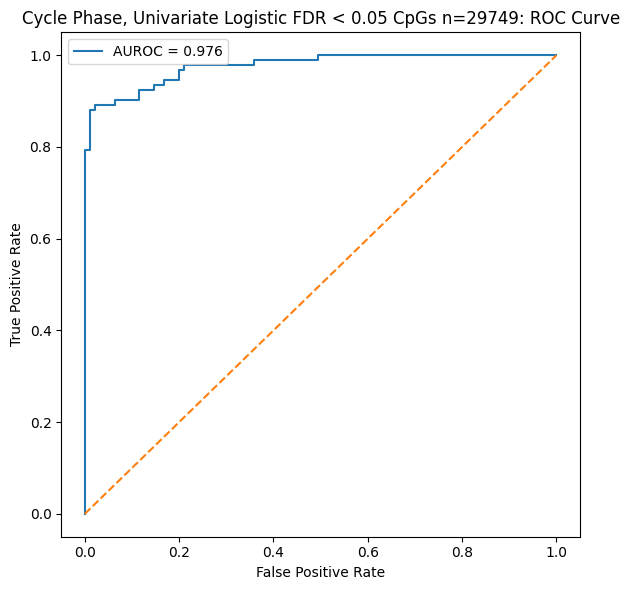

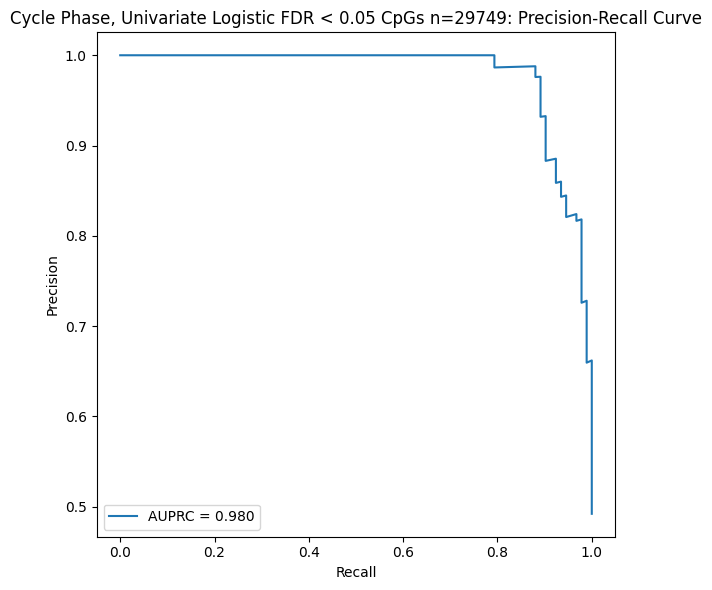

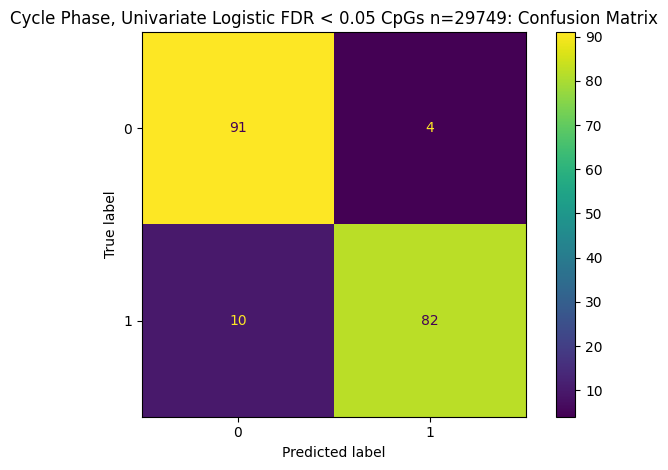

In [36]:
if cp_uni_n > 0:
    cp_uni_metrics = evaluate_binary_model(
        model=ridge_cp_uni,
        X_test=X_test_cp_uni_sel,
        y_test=y_test_cp,
        out_prefix=os.path.join(
            cp_uni_out_dir,
            f"cycle_phase_univariate_logistic_FDR_0.05_n{cp_uni_n}_ridge"
        ),
        plot_title=f"Cycle Phase, Univariate Logistic FDR < 0.05 CpGs n={cp_uni_n}"
    )

    cp_uni_metrics
else:
    cp_uni_metrics = pd.DataFrame([{
        "AUROC": np.nan,
        "AUPRC": np.nan,
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "Note": "No CpGs passed univariate logistic FDR < 0.05; model skipped"
    }])

    cp_uni_metrics

In [37]:
comparison_rows = []

cc_ttest_row = cc_ttest_metrics.copy()
cc_ttest_row.insert(0, "Outcome", "Case vs Control")
cc_ttest_row.insert(1, "Feature_Selection", f"T-test FDR < 0.05 n={cc_ttest_n}")
comparison_rows.append(cc_ttest_row)

cc_uni_row = cc_uni_metrics.copy()
cc_uni_row.insert(0, "Outcome", "Case vs Control")
cc_uni_row.insert(1, "Feature_Selection", f"Univariate logistic FDR < 0.05 n={cc_uni_n}")
comparison_rows.append(cc_uni_row)

cp_ttest_row = cp_ttest_metrics.copy()
cp_ttest_row.insert(0, "Outcome", "Cycle Phase")
cp_ttest_row.insert(1, "Feature_Selection", f"T-test FDR < 0.05 n={cp_ttest_n}")
comparison_rows.append(cp_ttest_row)

cp_uni_row = cp_uni_metrics.copy()
cp_uni_row.insert(0, "Outcome", "Cycle Phase")
cp_uni_row.insert(1, "Feature_Selection", f"Univariate logistic FDR < 0.05 n={cp_uni_n}")
comparison_rows.append(cp_uni_row)

method_comparison = pd.concat(comparison_rows, ignore_index=True)

comparison_path = os.path.join(
    out_dir,
    "ttest_vs_univariate_logistic_FDR_0.05_ridge_metrics.csv"
)

method_comparison.to_csv(comparison_path, index=False)

print("Saved comparison table to:", comparison_path)
method_comparison

Saved comparison table to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_vs_univariate_logistic_FDR_0.05_ridge_metrics.csv


,Outcome,Feature_Selection,AUROC,AUPRC,Accuracy,Precision,Recall,F1,Note
0,Case vs Control,T-test FDR < 0.05 n=0,NaN,NaN,NaN,NaN,NaN,NaN,No CpGs passed FDR < 0.05; model skipped
1,Case vs Control,Univariate logistic FDR < 0.05 n=0,NaN,NaN,NaN,NaN,NaN,NaN,No CpGs passed univariate logistic FDR < 0.05;...
2,Cycle Phase,T-test FDR < 0.05 n=32386,0.977346,0.980442,0.925134,0.953488,0.891304,0.921348,NaN
3,Cycle Phase,Univariate logistic FDR < 0.05 n=29749,0.976316,0.979735,0.925134,0.953488,0.891304,0.921348,NaN
